In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy import stats

# df = pd.read_csv("traffic_analysis.csv")
df = pd.read_csv("traffic_analysis_grouped_vio.csv")

# replacing nan values of citation_issued with False
df["citation_issued"] = df["citation_issued"].astype("boolean")   # nullable boolean dtype
df["citation_issued"] = df["citation_issued"].fillna(False)
# print(df['citation_issued'].value_counts())
# print(np.mean(df['citation_issued']))

/var/folders/j8/sn2sl_p16gx7qlcmgrp_fmpr0000gn/T/ipykernel_14861/1295815145.py:8: DtypeWarning: Columns (0: officer_race, 1: officer_sex, 2: outcome, 3: raw_race, 4: raw_driver_race) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("traffic_analysis_grouped_vio.csv")


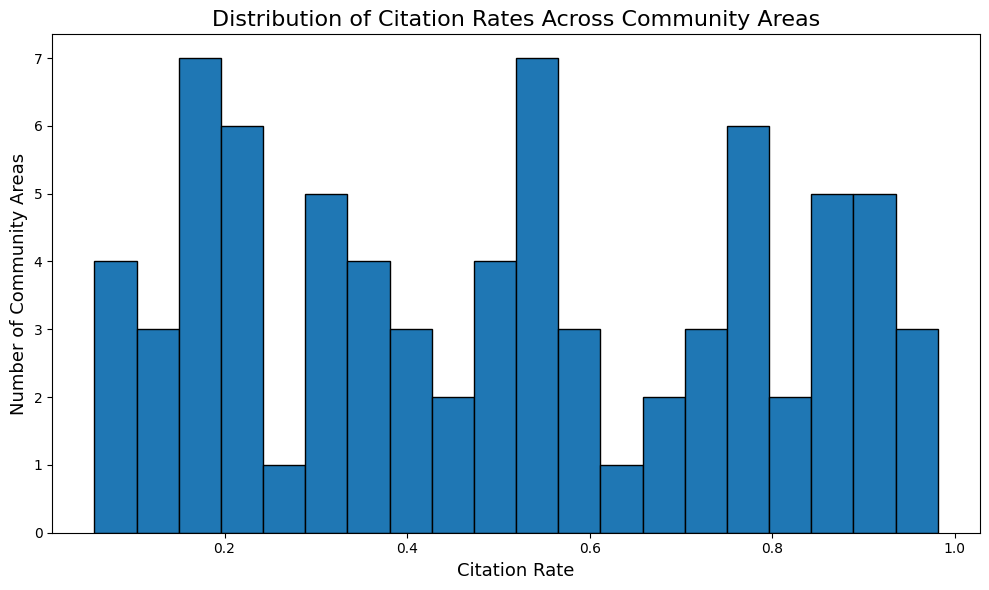

In [2]:
# MAKING HISTOGRAM OF DISTRIBUTION OF CITATION RATES IN EACH COMMUNITY AREA

# Compute citation rate per community area
citation_rates = df.groupby('community_area_id')['citation_issued'].mean()

# Define bin edges explicitly
bins = np.linspace(citation_rates.min(), citation_rates.max(), 21)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(citation_rates, edgecolor='black', bins=bins)
plt.xlabel('Citation Rate', fontsize=13)
plt.ylabel('Number of Community Areas', fontsize=13)
# plt.xticks(bins[::5], rotation=0, fontsize=8)
plt.title('Distribution of Citation Rates Across Community Areas', fontsize=16)
plt.tight_layout()
plt.show()

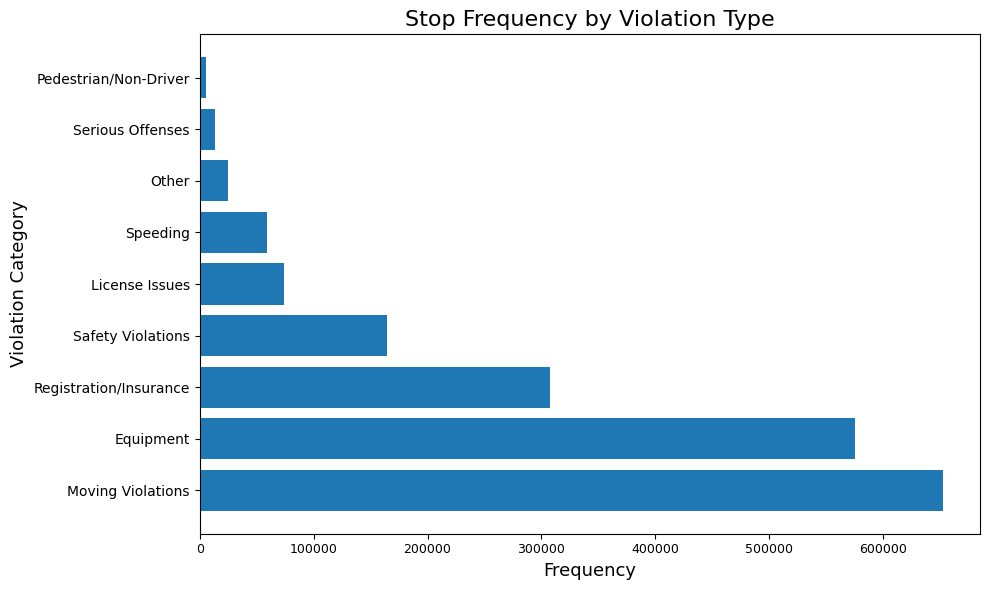

In [3]:
# MAKING VIOLATION CATEGORY STOP COUNT FREQUENCY BAR GRAPH

# Count and sort violations high to low
vio_counts = df['grouped_vio'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(vio_counts.index, vio_counts.values)
plt.xlabel('Frequency', fontsize=13)
plt.ylabel('Violation Category', fontsize=13)
plt.title('Stop Frequency by Violation Type', fontsize=16)
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

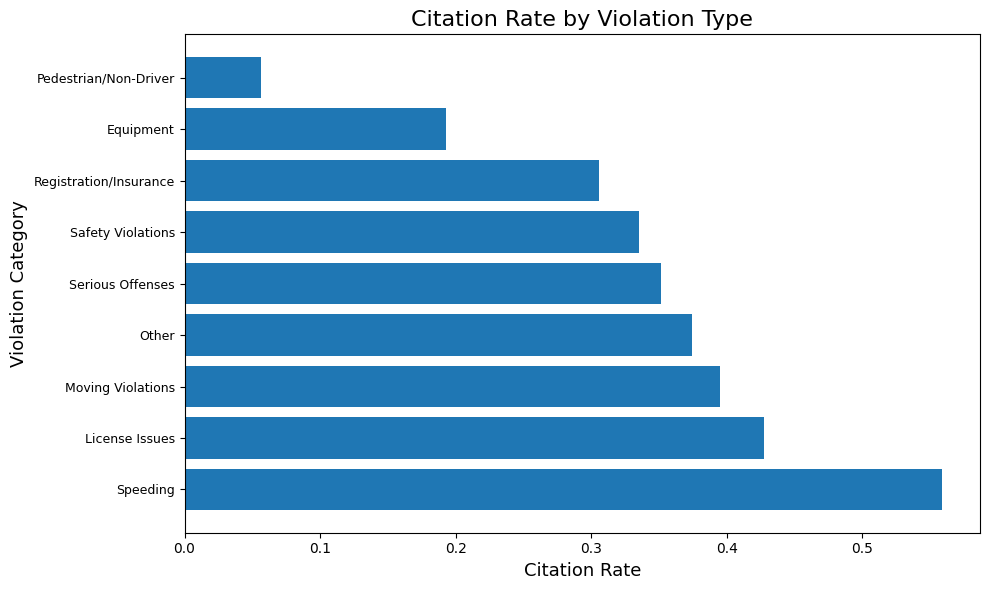

In [4]:
# MAKING BAR CHART OF CITATION RATE BY VIOLATION CATEGORY

# Compute citation rate per violation type
citation_rate_vio = df.groupby('grouped_vio')['citation_issued'].mean().sort_values(ascending=False)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(citation_rate_vio.index, citation_rate_vio.values)
plt.xlabel('Citation Rate', fontsize=13)
plt.ylabel('Violation Category', fontsize=13)
plt.title('Citation Rate by Violation Type', fontsize=16)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()